# Premier League 2025-26 Winner Predictor

Dixon-Coles bivariate Poisson model + Monte Carlo season simulation.

Pipeline:
1. Load football-data.co.uk match results for current + recent seasons
2. Split current season into played + remaining fixtures
3. Fit Dixon-Coles with time-decay weighting
4. Simulate the rest of the season N times
5. Aggregate title / top-4 / relegation probabilities

In [1]:
%load_ext autoreload
%autoreload 2
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_season, load_seasons, split_current_season
from src.model import fit_dixon_coles
from src.simulate import simulate_season, standings_with_simulation

pd.set_option('display.width', 140)
pd.set_option('display.max_rows', 30)

Matplotlib is building the font cache; this may take a moment.


## 1. Load data

In [2]:
CURRENT = 2025
HISTORY = 4

current = load_season(CURRENT)
state = split_current_season(current)
print(f'{len(state.played)} played, {len(state.remaining)} remaining')

history = load_seasons(range(CURRENT - HISTORY, CURRENT + 1))
history = history[history.HomeTeam.isin(state.teams) & history.AwayTeam.isin(state.teams)]
print(f'{len(history)} training matches across {history.Season.nunique()} seasons')
history.head()

349 played, 31 remaining
1473 training matches across 5 seasons


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,Season
0,2021-08-13,Brentford,Arsenal,2,0,H,2021-22
1,2021-08-14,Man United,Leeds,5,1,H,2021-22
2,2021-08-14,Burnley,Brighton,1,2,A,2021-22
3,2021-08-14,Chelsea,Crystal Palace,3,0,H,2021-22
8,2021-08-15,Newcastle,West Ham,2,4,A,2021-22


## 2. Current standings

In [3]:
state.standings

,Team,P,W,D,L,GF,GA,Pts,GD
0,Arsenal,35,23,7,5,67,26,76,41
1,Man City,34,21,8,5,69,32,71,37
2,Man United,35,18,10,7,63,48,64,15
3,Liverpool,35,17,7,11,59,47,58,12
4,Aston Villa,35,17,7,11,48,44,58,4
5,Bournemouth,35,12,16,7,55,52,52,3
6,Brentford,35,14,9,12,52,46,51,6
7,Brighton,35,13,11,11,49,42,50,7
8,Chelsea,35,13,9,13,54,48,48,6
9,Everton,35,13,9,13,44,44,48,0


## 3. Fit the Dixon-Coles model

- Half-life of 180 days: a match 6 months old contributes half as much weight as today's.
- Constraint: $\sum_i \alpha_i = 0$ for identifiability.
- `home` is the log home-advantage; `rho` is the low-score correction.


In [4]:
model = fit_dixon_coles(history, half_life_days=180, ref_date=current.Date.max(), teams=state.teams)
print(f'home advantage = {model.home:.3f}   rho = {model.rho:.3f}')
ratings = model.ratings_table()
ratings

home advantage = 0.187   rho = -0.107


,Team,Attack,Defense,Strength
0,Arsenal,0.306673,-0.325573,0.632246
1,Man City,0.374375,-0.109187,0.483562
2,Liverpool,0.291934,0.161981,0.129953
3,Man United,0.166262,0.196520,-0.030258
4,Brighton,0.063970,0.125243,-0.061273
5,Nott'm Forest,0.009120,0.109864,-0.100744
6,Bournemouth,0.122907,0.234628,-0.111721
7,Brentford,0.070404,0.206384,-0.135981
8,Chelsea,0.073793,0.227090,-0.153297
9,Aston Villa,0.026758,0.183940,-0.157182


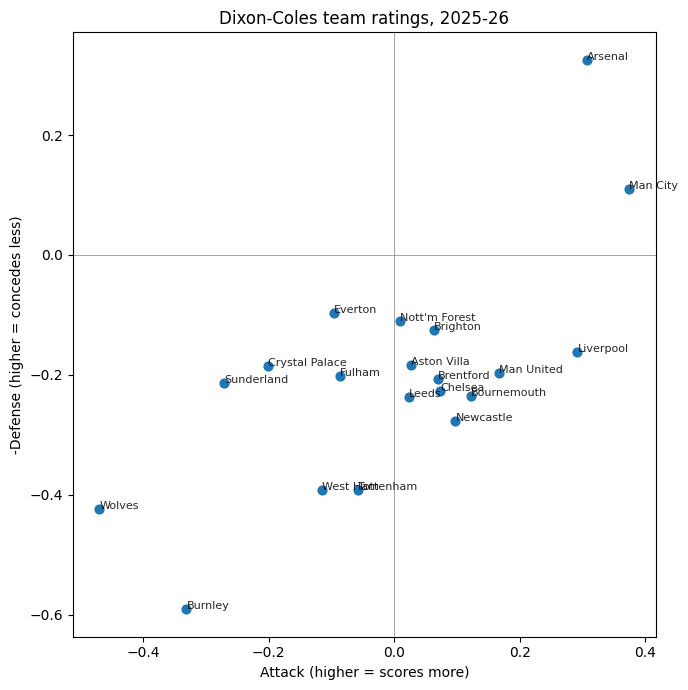

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ratings.Attack, -ratings.Defense, s=40)
for _, r in ratings.iterrows():
    ax.annotate(r.Team, (r.Attack, -r.Defense), fontsize=8, alpha=0.85)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Attack (higher = scores more)')
ax.set_ylabel('-Defense (higher = concedes less)')
ax.set_title('Dixon-Coles team ratings, 2025-26')
plt.tight_layout(); plt.show()

## 4. Probe the model: head-to-head outcomes

In [6]:
for h, a in [('Arsenal', 'Man City'), ('Liverpool', 'Arsenal'), ('Man City', 'Tottenham')]:
    lam, mu = model.expected_goals(h, a)
    probs = model.outcome_probs(h, a)
    print(f'{h:14s} vs {a:14s}  E[goals] {lam:.2f}-{mu:.2f}   H {probs["H"]:.2%}  D {probs["D"]:.2%}  A {probs["A"]:.2%}')

Arsenal        vs Man City        E[goals] 1.47-1.05   H 45.44%  D 28.84%  A 25.72%
Liverpool      vs Arsenal         E[goals] 1.17-1.60   H 26.55%  D 27.31%  A 46.13%
Man City       vs Tottenham       E[goals] 2.59-0.85   H 74.12%  D 16.71%  A 9.18%


## 5. Monte Carlo the rest of the season

In [7]:
result = simulate_season(state, model, n_runs=20000, seed=7)
summary = standings_with_simulation(state, result)
summary

simulating:   0%|          | 0/20000 [00:00<?, ?season/s]

simulating:  10%|▉         | 1915/20000 [00:00<00:00, 19137.97season/s]

simulating:  20%|█▉        | 3936/20000 [00:00<00:00, 19764.27season/s]

simulating:  30%|███       | 6082/20000 [00:00<00:00, 20535.84season/s]

simulating:  41%|████▏     | 8253/20000 [00:00<00:00, 20998.50season/s]

...

simulating:  74%|███████▍  | 14823/20000 [00:00<00:00, 20771.34season/s]

simulating:  85%|████████▍ | 16928/20000 [00:00<00:00, 20857.23season/s]

simulating:  95%|█████████▌| 19085/20000 [00:00<00:00, 21075.18season/s]

simulating: 100%|██████████| 20000/20000 [00:00<00:00, 20933.84season/s]

,P,W,D,L,GF,GA,Pts,GD,P(Champion),P(Top 4),P(Relegation),ExpPts,ExpPos
Team,,,,,,,,,,,,,
Arsenal,35,23,7,5,67,26,76,41,0.8694,1.0000,0.0000,82.9,1.13
Man City,34,21,8,5,69,32,71,37,0.1306,1.0000,0.0000,79.3,1.87
Man United,35,18,10,7,63,48,64,15,0.0000,0.9990,0.0000,68.4,3.07
Liverpool,35,17,7,11,59,47,58,12,0.0000,0.7104,0.0000,63.2,4.24
Aston Villa,35,17,7,11,48,44,58,4,0.0000,0.2886,0.0000,61.8,4.76
Bournemouth,35,12,16,7,55,52,52,3,0.0000,0.0011,0.0000,55.5,7.48
Brentford,35,14,9,12,52,46,51,6,0.0000,0.0006,0.0000,54.3,8.12
Brighton,35,13,11,11,49,42,50,7,0.0000,0.0003,0.0000,55.0,7.46
Chelsea,35,13,9,13,54,48,48,6,0.0000,0.0000,0.0000,52.2,9.71


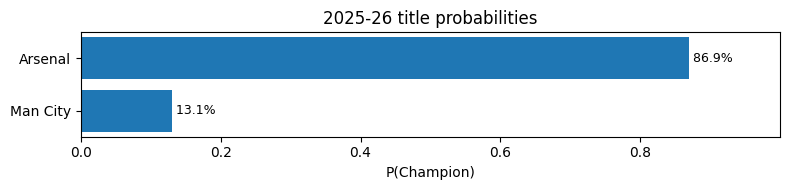

In [8]:
title = result.title.sort_values(ascending=True)
title = title[title > 0]
fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(title))))
ax.barh(title.index, title.values)
for i, v in enumerate(title.values):
    ax.text(v, i, f' {v:.1%}', va='center', fontsize=9)
ax.set_xlabel('P(Champion)')
ax.set_title('2025-26 title probabilities')
ax.set_xlim(0, max(title.values) * 1.15)
plt.tight_layout(); plt.show()

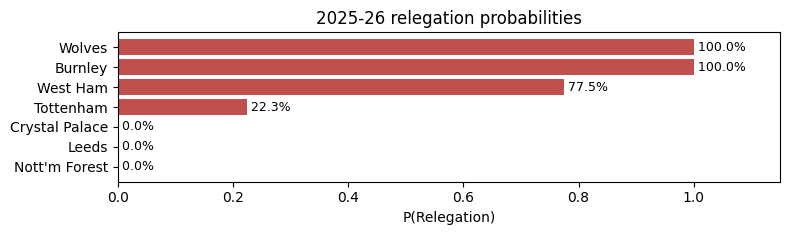

In [9]:
rel = result.relegation.sort_values(ascending=True)
rel = rel[rel > 0]
fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(rel))))
ax.barh(rel.index, rel.values, color='#c0504d')
for i, v in enumerate(rel.values):
    ax.text(v, i, f' {v:.1%}', va='center', fontsize=9)
ax.set_xlabel('P(Relegation)')
ax.set_title('2025-26 relegation probabilities')
ax.set_xlim(0, max(rel.values) * 1.15)
plt.tight_layout(); plt.show()

## 6. Sensitivity: half-life choice

How much does the answer move if we recency-weight more or less aggressively?

In [10]:
rows = []
for hl in [90, 180, 365, 730]:
    m = fit_dixon_coles(history, half_life_days=hl, ref_date=current.Date.max(), teams=state.teams)
    r = simulate_season(state, m, n_runs=5000, seed=7, show_progress=False)
    top = r.title.sort_values(ascending=False).head(3)
    rows.append({'half_life_days': hl, **{t: f'{p:.1%}' for t, p in top.items()}})
pd.DataFrame(rows)

,half_life_days,Arsenal,Man City,Aston Villa
0,90,87.7%,12.3%,0.0%
1,180,87.1%,12.9%,0.0%
2,365,84.9%,15.1%,0.0%
3,730,80.9%,19.1%,0.0%
